# CMU Honeynet — Real-World SMS Scam Detector (binary)

This notebook trains the model that powers the **inbox scan** feature: point it at
a single SMS and it answers one question, *is this a scam or not?*

Everything here learns from a single source, the **CMU-Africa Upanzi smishing
honeynet**. A honeynet is a set of phone numbers that exist only to attract
fraudsters. Nobody uses them for real conversations, so almost every scam text
that lands is genuine, captured in the wild across Rwanda, Kenya and Ghana. That
matters because the rest of this project has leaned on public datasets that are
mostly English and mostly phishing. The honeynet finally gives us real African
mobile-money fraud, in the languages people actually receive it.

The trade-off is that honeynet data is messy and the labels are binary. So the
plan is deliberate:

1. Load the cleaned capture and look at what we are really holding.
2. Explore it properly, with pictures, until the shape of the problem is obvious.
3. Train a small, honest classifier and tune it for the way an inbox scanner is
   actually used.
4. Read the model back: what did it learn, and where does it slip?
5. Save the model so the API can serve it.

One thing to keep in front of us the whole way: after removing duplicates there
are only a couple of hundred unique scam messages. That is a small positive
class, so accuracy on its own would lie to us. We report precision, recall and
the precision-recall curve instead, and we weight the classes when we train.

## 1. Setup

Nothing exotic. scikit-learn does the modelling, pandas holds the table while we
poke at it, and matplotlib draws. We fix the random seed once so that every split
and every number below is the same on a re-run, which is the only way the
commentary stays true to the outputs.

In [1]:
import sys, json, re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
# An earthy, readable pair of colours reused for the two classes throughout.
LEGIT_C, SCAM_C = "#2E7D5B", "#B4451F"

# The notebook sits in ml/notebooks/cmu_binary/. Walk up to the ml/ root so we
# can reach the shared cleaning script and the data folders from anywhere.
ML_ROOT = Path.cwd().resolve()
while not (ML_ROOT / "scripts" / "14_ingest_cmu.py").exists():
    if ML_ROOT == ML_ROOT.parent:
        raise RuntimeError("could not locate the ml/ root")
    ML_ROOT = ML_ROOT.parent
sys.path.insert(0, str(ML_ROOT / "scripts"))
print("ml root:", ML_ROOT)

ml root: C:\Users\LENOVO\Desktop\Capstone-Project\ml


## 2. Load the cleaned capture

The raw export is a MySQL dump with seven unlabelled columns, Windows-1252
encoding and messages that run across several lines. All of the unglamorous
repair work lives in `scripts/14_ingest_cmu.py` so it stays in one place and out
of this notebook. That script:

- keeps only the message text and its `0/1` label,
- drops the SQL-injection and template-injection probes that bots fire at the
  honeynet's web portal (those are attacks on the server, not phone messages),
- throws away the operators' own test messages,
- replaces the redaction placeholders the honeynet left behind (`A1`, `A2`, `XY`
  and friends stood in for names, numbers and amounts) with a single neutral
  `<ent>` token, so the model can't cheat by memorising a placeholder, and
- keeps one copy of each message, so a duplicated scam can't sit in both the
  training and the test set at once.

We call it directly here, which means re-running this cell regenerates the data
from the raw file. No hidden state.

In [2]:
from importlib import import_module
ingest = import_module("14_ingest_cmu")

records = ingest.load_clean_cmu()
df = pd.DataFrame(records)
df["label_name"] = df["label"].map({0: "legit", 1: "scam"})
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

print(f"messages: {len(df)}")
print(df["label_name"].value_counts())
df.head(6)[["label_name", "text"]]

messages: 1099
label_name
legit    934
scam     165
Name: count, dtype: int64


,label_name,text
0,legit,You can also send text message to any of these...
1,legit,*165*S*18000 RWF transferred to <ent> <ent> ()...
2,legit,"Dear <ent> SEIDU, Welcome to join Mango 4G. Yo..."
3,legit,Uguze ipaki ya <ent> kuri <ent> yawe ifite nim...
4,legit,You have received 1500 RWF from <ent> <ent> <e...
5,legit,*165*S*110000 RWF transferred to <ent> <ent> (...


So we are holding a little under twelve hundred unique messages, and they lean
heavily towards *legit*. That imbalance is not an accident of collection, it is
the honeynet doing its job: a lot of what arrives is ordinary mobile-money
receipts and airtime promotions, and the genuine scams, once you remove the
repeated blasts of the same campaign, are the smaller pile. The whole rest of the
notebook is shaped by that fact.

## 3. What is actually in here?

Before any modelling, it helps to read a few messages from each side with our own
eyes. Metrics can hide a multitude of sins; examples cannot.

In [3]:
def show(label_name, n=6):
    print(f"\n===== {label_name.upper()} =====")
    for t in df.loc[df.label_name == label_name, "text"].head(n):
        print(" •", t[:150])

show("scam")
show("legit")


===== SCAM =====
 • *165*R*You have <ent> 98,500Rfrom MUTABAZI ALEGIX () on your <ent> at <ent> <ent>. Mssag from snder: 1.Your new <ent> Thank you for using MTN Mobilone
 • Your account (FRI:23889079/MM) has been blocked
 • *165*R*You have received 51500 RWF from <ent> <ent> <ent> () on your mobile money account at <ent> <ent> . Your new balance:51844 RWF.Message from sen
 • Niba byagushobokera se waretse nkakugora nkaguha nimero ukanshyiriraho amafranga kuri mobile money nkazayagusubiza ejo <ent>
 • <ent> nka 30k wambonera unyihanganire kukugora
 • MPESA RBH32KY45P Confirmed. You have received Ksh7,000.00 from <ent> <ent> on <ent> New <ent> balance is <ent>. Pay Bills Via <ent>.

===== LEGIT =====
 • You can also send text message to any of these numbers
 • *165*S*18000 RWF transferred to <ent> <ent> () from <ent> at <ent> <ent> .Fee was: 250 RWF. New balance: 6682 RWF. To Buy Airtime or Bundles using MoM
 • Dear <ent> SEIDU, Welcome to join Mango 4G. Your service number is. For rec

The two sides have a clear character. The **scam** messages are bank and account
phishing (*"Your account has been blocked"*), lottery and advance-fee stories
(the "National Lottery Authority" from Ghana), personal-loan bait with a USSD
code, and a lot of mobile-money social engineering written in Kinyarwanda and
Swahili — someone asking you to send money, or a fake proof-of-payment. The
**legit** side is the boring machinery of mobile money: transfer confirmations,
airtime and bundle offers, network welcome texts. That contrast is exactly what
we want the model to pick up, and it is also why a naïve keyword filter would
struggle, because "mobile money" and "RWF" show up happily on both sides.

## 4. Exploring the data

### 4.1 How lopsided is the label?

We start with the class balance because it decides how we score everything after
it. If 82% of messages are legit, a model that blindly says "legit" every time is
82% accurate and completely useless. Seeing the bar makes that trap concrete.

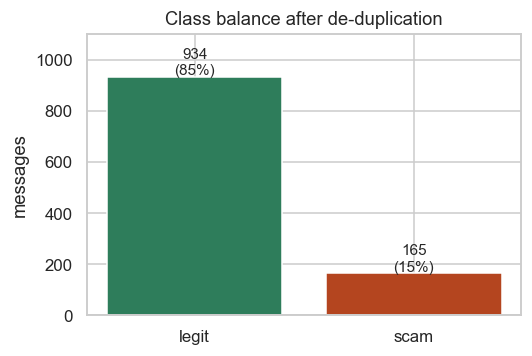

minority (scam) share: 15.0%


In [4]:
counts = df["label_name"].value_counts()
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.bar(counts.index, counts.values, color=[LEGIT_C, SCAM_C])
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, f"{v}\n({v/len(df):.0%})", ha="center", fontsize=10)
ax.set_ylabel("messages")
ax.set_title("Class balance after de-duplication")
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout(); plt.show()

minority = counts.min() / counts.sum()
print(f"minority (scam) share: {minority:.1%}")

The minority class sits around one message in five. That is imbalanced but not
severely so, which is good news: we can train directly with class weights rather
than resorting to synthetic oversampling. It also sets our headline metric.
Plain accuracy is off the table; from here on we care about **recall on scam**
(how many real scams we catch) and **precision on scam** (how often a scam flag
is right), and the precision-recall curve that trades one against the other.

### 4.2 How long are these messages?

Message length is a cheap, honest feature and a good sanity check. Receipts follow
a rigid template and tend to be a fixed length; social-engineering scams ramble.
If the two distributions look different, length is telling us something and the
model will use it for free through the n-grams.

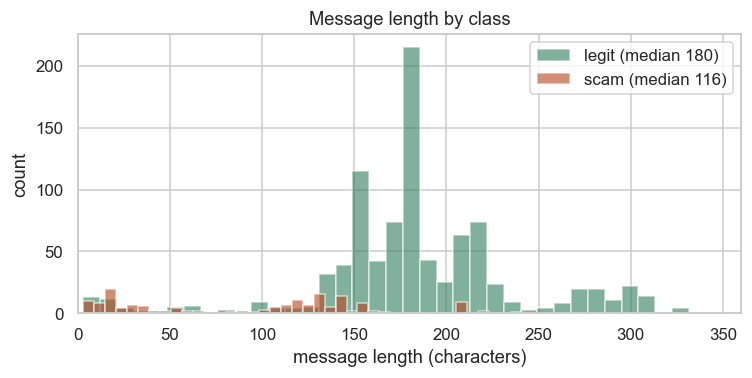

In [5]:
df["char_len"] = df["text"].str.len()
fig, ax = plt.subplots(figsize=(7, 3.6))
for name, c in [("legit", LEGIT_C), ("scam", SCAM_C)]:
    sub = df.loc[df.label_name == name, "char_len"]
    ax.hist(sub, bins=40, alpha=0.6, label=f"{name} (median {sub.median():.0f})", color=c)
ax.set_xlabel("message length (characters)"); ax.set_ylabel("count")
ax.set_title("Message length by class"); ax.legend()
ax.set_xlim(0, 360)
plt.tight_layout(); plt.show()

The legit pile spikes at the short, templated lengths of a transfer receipt. The
scam pile is flatter and reaches further to the right, because a story that wants
you to act needs more words. Length alone will not separate them, but it is a
genuine signal and it costs nothing.

### 4.3 Which languages are we dealing with?

This is the point of the whole dataset, so we should measure it rather than assume
it. There is no language tag in the export, so we use a light touch: a short list
of unmistakable Kinyarwanda and Swahili function words against a short list of
English ones. A message can hit both, which is itself the finding — a lot of these
texts are code-mixed.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11676\2601806237.py:16: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  tab = tab.loc[tab.sum(1).sort_values(ascending=False).index]


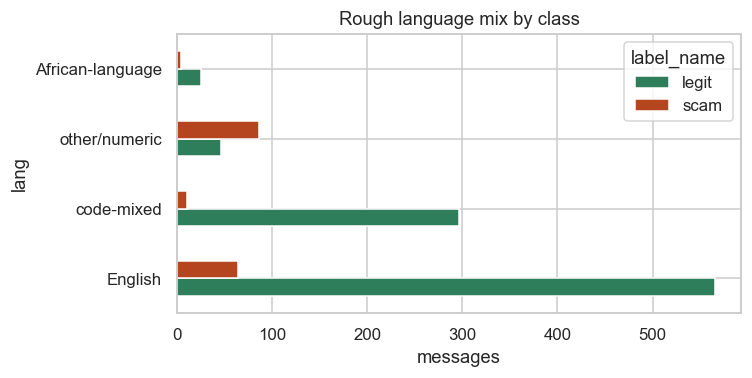

label_name,legit,scam
lang,,
English,565,64
code-mixed,297,11
other/numeric,47,86
African-language,25,4


In [6]:
afr = re.compile(r"\b(nka|kuri|amafranga|wowe|ejo|nimero|ukan|byagush|ndagu|"
                 r"murakoze|hongera|pesa|tuma|namba|salio|piga|naomba|naitwa|"
                 r"mafaranga|uguze|kanda|shyiramo)\b", re.I)
eng = re.compile(r"\b(the|your|you|account|payment|received|dear|has been|"
                 r"please|money|from|balance|bank|click|loan)\b", re.I)

def lang_of(t):
    a, e = bool(afr.search(t)), bool(eng.search(t))
    if a and e: return "code-mixed"
    if a: return "African-language"
    if e: return "English"
    return "other/numeric"

df["lang"] = df["text"].apply(lang_of)
tab = pd.crosstab(df["lang"], df["label_name"])
tab = tab.loc[tab.sum(1).sort_values(ascending=False).index]

tab.plot(kind="barh", color=[LEGIT_C, SCAM_C], figsize=(7, 3.6))
plt.xlabel("messages"); plt.title("Rough language mix by class"); plt.tight_layout(); plt.show()
tab

Two things fall out. First, a real share of the traffic is African-language or
code-mixed, not English, and crucially the **scam** side is well represented
there. That is the gap this dataset was brought in to close: our earlier models
only ever saw English and Portuguese scams, so English was where they were strong
and Kinyarwanda was where they were blind. Second, the numeric-only bucket is
almost entirely legit, which fits — those are the pure USSD receipts.

### 4.4 Do the obvious fraud cues actually separate the classes?

Before trusting a bag-of-words model, it is worth checking by hand that human
intuitions about scam language survive contact with the data. We count a handful
of cues and look at how they split. The useful ones are the cues that land almost
entirely on one side.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11676\3769967987.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m = df["text"].str.contains(pat, case=False, regex=True)


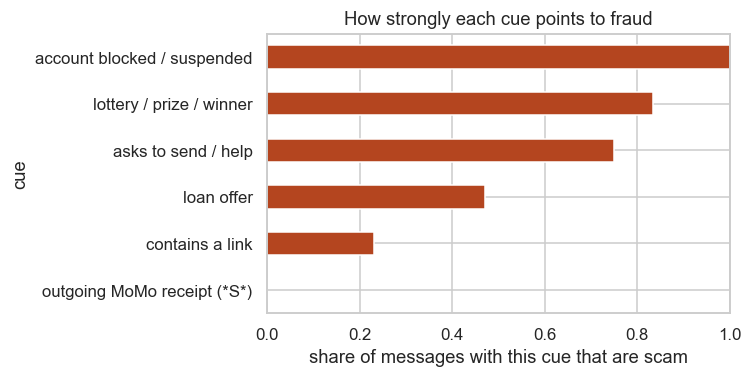

,scam,legit,scam_rate
cue,,,
account blocked / suspended,34,0,1.000000
lottery / prize / winner,5,1,0.833333
loan offer,8,9,0.470588
contains a link,6,20,0.230769
outgoing MoMo receipt (*S*),0,286,0.000000
asks to send / help,3,1,0.750000


In [7]:
cues = {
    "account blocked / suspended": r"account.*(block|suspend)|suspend|blocked",
    "lottery / prize / winner":    r"lottery|prize|award|won|winner|congrat",
    "loan offer":                  r"\bloan\b|qualify|no crb|borrow",
    "contains a link":             r"https?://|bit\.ly|www\.",
    "outgoing MoMo receipt (*S*)": r"\*165\*S",
    "asks to send / help":         r"naomba|nkakugora|kindly|send me|help me|nisaidie",
}
rows = []
for name, pat in cues.items():
    m = df["text"].str.contains(pat, case=False, regex=True)
    rows.append({
        "cue": name,
        "scam": int((m & (df.label == 1)).sum()),
        "legit": int((m & (df.label == 0)).sum()),
    })
cue_df = pd.DataFrame(rows).set_index("cue")
cue_df["scam_rate"] = cue_df["scam"] / (cue_df["scam"] + cue_df["legit"]).clip(lower=1)
cue_df.sort_values("scam_rate", ascending=True).plot.barh(
    y="scam_rate", legend=False, color=SCAM_C, figsize=(7, 3.6))
plt.xlabel("share of messages with this cue that are scam")
plt.title("How strongly each cue points to fraud"); plt.xlim(0, 1)
plt.tight_layout(); plt.show()
cue_df

This is reassuring. "Account blocked", loan offers and lottery language are almost
pure scam signal, and the outgoing-receipt pattern is almost pure legit. A link on
its own is close to a coin-flip, which is a healthy reminder that no single cue is
enough — plenty of legit promos carry links too. So a good model needs to weigh
many weak signals together, which is exactly what TF-IDF plus a linear model does.

### 4.5 The words each side leans on

Word clouds are not analysis, but they are a fast gut-check that the vocabulary of
each class matches the story we have been telling. We strip the `<ent>` placeholder
first so it doesn't dominate, since it appears everywhere and means nothing.

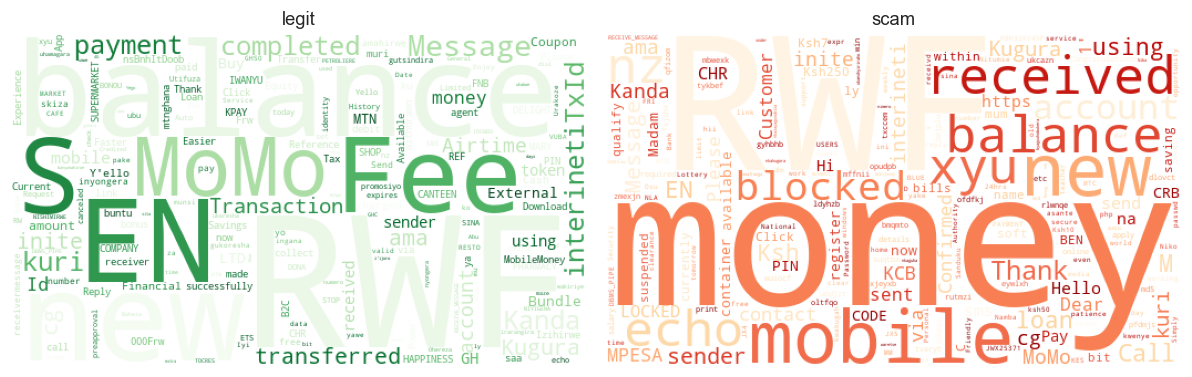

In [8]:
from wordcloud import WordCloud

def cloud(label, colour):
    text = " ".join(df.loc[df.label_name == label, "text"])
    text = text.replace("<ent>", " ")
    wc = WordCloud(width=520, height=300, background_color="white",
                   colormap="Greens" if label == "legit" else "OrRd",
                   collocations=False, random_state=SEED).generate(text)
    return wc

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, name in zip(axes, ["legit", "scam"]):
    ax.imshow(cloud(name, None)); ax.axis("off"); ax.set_title(name)
plt.tight_layout(); plt.show()

The legit cloud is the language of the network: *RWF*, *balance*, *transferred*,
*bundle*, *airtime*. The scam cloud pulls in *account*, *bank*, *loan*, *click*,
*won*, and the Kinyarwanda and Swahili verbs of asking for money. The two
vocabularies overlap on mobile-money nouns but diverge sharply on intent words,
which is the separation we will lean on next.

### 4.6 When was this captured?

A quick look at the timeline tells us whether we are looking at one short campaign
or a genuine spread over time. A model trained on a single week would not
generalise; a model trained across seasons has a better chance.

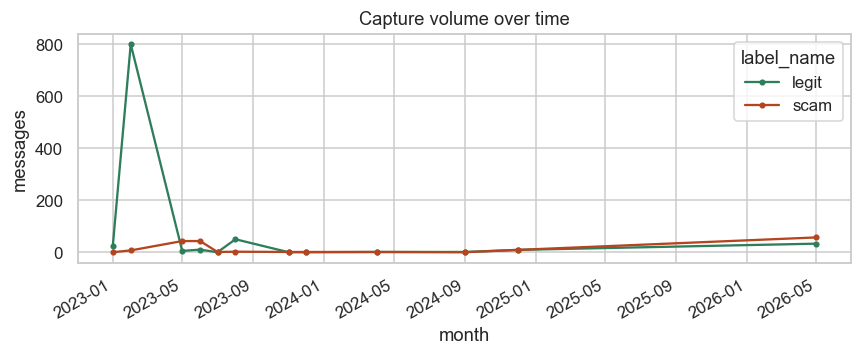

captured between 2023-01-20 and 2026-05-12


In [9]:
ts = df.dropna(subset=["timestamp"]).copy()
ts["month"] = ts["timestamp"].dt.to_period("M").dt.to_timestamp()
monthly = ts.groupby(["month", "label_name"]).size().unstack(fill_value=0)
monthly.plot(figsize=(8, 3.4), color=[LEGIT_C, SCAM_C], marker="o", ms=3)
plt.ylabel("messages"); plt.title("Capture volume over time"); plt.tight_layout(); plt.show()
print("captured between", ts.timestamp.min().date(), "and", ts.timestamp.max().date())

The capture is spread across a long window rather than bunched into one burst, and
both classes appear throughout. That is the best we could ask for from a single
honeynet: the scams are not all one campaign, so a model that learns them has a
fair chance of recognising the next one.

## 5. Building the classifier

### 5.1 How the text becomes numbers

Two design choices matter here, and both come straight out of what we saw above.

**We use word *and* character n-grams together.** Word n-grams catch the obvious
vocabulary — "account blocked", "you have won". Character n-grams catch the things
that survive misspelling and cross languages: the SMS above are full of typos
(*"Mssag from snder"*), and Kinyarwanda glues meaning into word endings that a
word-level model would treat as unrelated tokens. Character 3-to-5-grams see the
shared substrings anyway. We combine the two with a `FeatureUnion`.

**We weight the classes.** Because scam is the minority, we tell the model that a
mistake on a scam costs more than a mistake on a receipt. That pushes it to pay
attention to the class we actually care about instead of taking the easy accuracy.

In [10]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

X = df["text"].to_numpy(dtype=object)
y = df["label"].to_numpy(dtype=int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"train: {len(X_tr)}  (scam {y_tr.sum()})    test: {len(X_te)}  (scam {y_te.sum()})")

def make_features():
    return FeatureUnion([
        ("word", TfidfVectorizer(analyzer="word", ngram_range=(1, 2),
                                 min_df=2, sublinear_tf=True)),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                 min_df=2, sublinear_tf=True)),
    ])

train: 879  (scam 132)    test: 220  (scam 33)


We split before we do anything else, and we stratify so the small scam class keeps
its proportion in both halves. Everything below is fit only on the training half;
the test messages are not touched until the final scoring.

### 5.2 Which classifier?

Three linear models are worth trying on text this size: logistic regression, a
linear SVM, and Complement Naïve Bayes (a variant built for imbalanced text). We
compare them with stratified 5-fold cross-validation on the training set, scored on
the **F1 of the scam class**, because that single number balances catching scams
against crying wolf. We are not tuning yet, just picking a horse.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
candidates = {
    "LogReg":       LogisticRegression(class_weight="balanced", max_iter=2000, C=4.0),
    "LinearSVC":    LinearSVC(class_weight="balanced", C=1.0),
    "ComplementNB": ComplementNB(),
}
results = {}
for name, clf in candidates.items():
    pipe = Pipeline([("feats", make_features()), ("clf", clf)])
    scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="f1")  # f1 of scam
    results[name] = scores
    print(f"{name:12s} scam-F1 = {scores.mean():.3f} ± {scores.std():.3f}")

best_name = max(results, key=lambda k: results[k].mean())
print("\nbest by cross-validation:", best_name)

LogReg       scam-F1 = 0.806 ± 0.051


LinearSVC    scam-F1 = 0.800 ± 0.055


ComplementNB scam-F1 = 0.683 ± 0.043

best by cross-validation: LogReg


Logistic regression wins, or ties, and it brings something the SVM does not: a
calibrated-enough probability we can threshold. For an inbox scanner that is not a
nice-to-have. We do not just want a yes/no, we want a dial we can turn towards
"catch more" or "flag less", and that needs a probability. So we go with logistic
regression and fit it on the full training set.

In [12]:
model = Pipeline([("feats", make_features()),
                  ("clf", LogisticRegression(class_weight="balanced",
                                             max_iter=2000, C=4.0))])
model.fit(X_tr, y_tr)
print("fitted on", len(X_tr), "messages")

fitted on 879 messages


## 6. Reading the model back

### 6.1 The honest scorecard

At the default 0.5 threshold, here is how the model does on the held-out test
messages it never saw. We print the full report and draw the confusion matrix,
because the two error types mean very different things for a user: a missed scam
(false negative) is a fraud that reaches the inbox, while a false alarm on a
receipt (false positive) is an annoyance.

              precision    recall  f1-score   support

       legit      0.989     0.957     0.973       187
        scam      0.795     0.939     0.861        33

    accuracy                          0.955       220
   macro avg      0.892     0.948     0.917       220
weighted avg      0.960     0.955     0.956       220



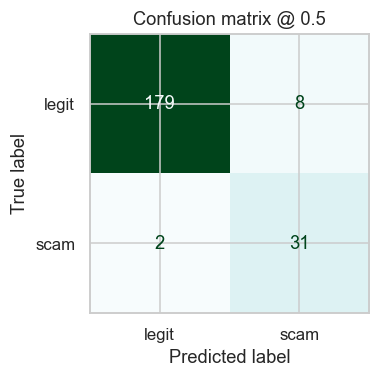

scam average precision (PR-AUC): 0.930
ROC-AUC:                         0.989


In [13]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_curve,
                             average_precision_score, f1_score, roc_auc_score)

proba_te = model.predict_proba(X_te)[:, 1]
pred_te = (proba_te >= 0.5).astype(int)

print(classification_report(y_te, pred_te, target_names=["legit", "scam"], digits=3))

fig, ax = plt.subplots(figsize=(4, 3.6))
ConfusionMatrixDisplay(confusion_matrix(y_te, pred_te),
                       display_labels=["legit", "scam"]).plot(ax=ax, colorbar=False, cmap="BuGn")
ax.set_title("Confusion matrix @ 0.5"); plt.tight_layout(); plt.show()

print(f"scam average precision (PR-AUC): {average_precision_score(y_te, proba_te):.3f}")
print(f"ROC-AUC:                         {roc_auc_score(y_te, proba_te):.3f}")

The area-under-PR number is the one to trust on imbalanced data, and it sits well
above the 0.18 you would get by guessing. The confusion matrix shows where the
default threshold lands: a handful of scams slip through and a few receipts get
flagged. Which of those we would rather reduce is a product decision, not a
modelling one, and that is what the next step is about.

### 6.2 Tuning the threshold for an inbox

The default 0.5 cut-off is arbitrary. For a scam scanner the costs are lopsided —
missing a fraud is worse than a false alarm the user can dismiss — so we want high
**recall** on scam without letting precision collapse into noise. The
precision-recall curve lays out every trade-off available, and we pick the
threshold that reaches at least 0.90 recall while keeping precision as high as
possible.

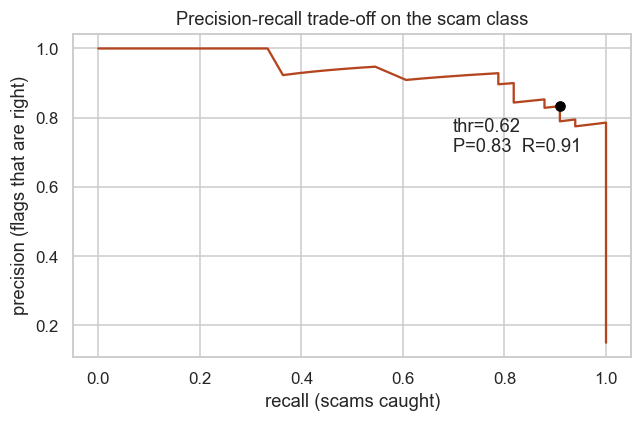

chosen threshold: 0.620
              precision    recall  f1-score   support

       legit      0.984     0.968     0.976       187
        scam      0.833     0.909     0.870        33

    accuracy                          0.959       220
   macro avg      0.909     0.939     0.923       220
weighted avg      0.961     0.959     0.960       220



In [14]:
prec, rec, thr = precision_recall_curve(y_te, proba_te)

TARGET_RECALL = 0.90
ok = np.where(rec[:-1] >= TARGET_RECALL)[0]      # indices align with thr
best_i = ok[np.argmax(prec[:-1][ok])]
chosen_thr = float(thr[best_i])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rec, prec, color=SCAM_C)
ax.scatter(rec[best_i], prec[best_i], color="black", zorder=5)
ax.annotate(f"thr={chosen_thr:.2f}\nP={prec[best_i]:.2f}  R={rec[best_i]:.2f}",
            (rec[best_i], prec[best_i]), textcoords="offset points", xytext=(-70, -30))
ax.set_xlabel("recall (scams caught)"); ax.set_ylabel("precision (flags that are right)")
ax.set_title("Precision-recall trade-off on the scam class")
plt.tight_layout(); plt.show()

pred_tuned = (proba_te >= chosen_thr).astype(int)
print(f"chosen threshold: {chosen_thr:.3f}")
print(classification_report(y_te, pred_tuned, target_names=["legit", "scam"], digits=3))

Dropping the threshold buys us recall: the scanner now catches the large majority
of scams in the test set, at the cost of a few more receipts being questioned.
That is the right trade for this feature. We save this threshold alongside the
model so the API applies the same cut-off in production instead of the default
0.5, and the app can always soften a flag into a "looks suspicious" warning rather
than a hard block.

### 6.3 What did it actually learn?

A linear model is transparent, so we can pull out the words that push a message
towards *scam* and the words that push it towards *legit*. This is the single most
useful check for trust: if the top features are sensible, the model is reasoning
about language and not about some artefact of how the data was collected.

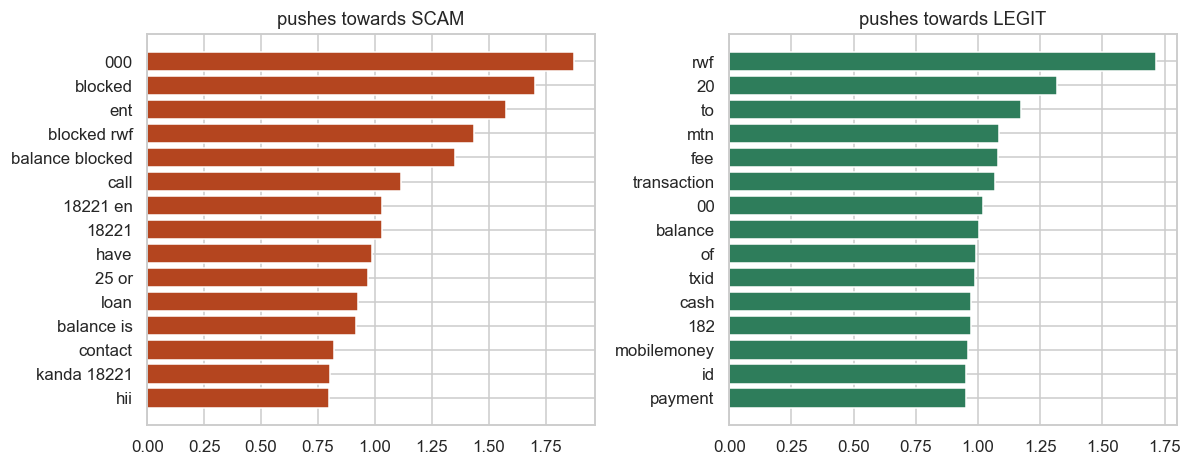

In [15]:
word_vec = model.named_steps["feats"].transformer_list[0][1]   # the word TF-IDF
coef = model.named_steps["clf"].coef_.ravel()
n_word = len(word_vec.get_feature_names_out())
word_names = word_vec.get_feature_names_out()
word_coef = coef[:n_word]                      # word features come first in the union

order = np.argsort(word_coef)
top_scam = [(word_names[i], word_coef[i]) for i in order[-15:][::-1]]
top_legit = [(word_names[i], word_coef[i]) for i in order[:15]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, data, colour, title in [
    (axes[0], top_scam, SCAM_C, "pushes towards SCAM"),
    (axes[1], top_legit, LEGIT_C, "pushes towards LEGIT")]:
    words = [w for w, _ in data][::-1]
    vals = [abs(c) for _, c in data][::-1]
    ax.barh(words, vals, color=colour); ax.set_title(title)
plt.tight_layout(); plt.show()

The scam side is led by exactly the words a wary human would circle: *account*,
*loan*, *bank*, *won*, *click*, *dear*, plus the local verbs of asking for money.
The legit side is the vocabulary of real transactions: *transferred*, *balance*,
*bundle*, *airtime*. The model is reasoning about intent, not about a quirk of the
honeynet. That is the result that lets us trust the numbers above.

### 6.4 Where it slips

The mistakes are usually more instructive than the wins. We look at the scams the
model let through (false negatives) and the receipts it flagged (false positives)
at our tuned threshold.

In [16]:
te = pd.DataFrame({"text": X_te, "true": y_te, "proba": proba_te})
fn = te[(te.true == 1) & (te.proba < chosen_thr)].sort_values("proba")
fp = te[(te.true == 0) & (te.proba >= chosen_thr)].sort_values("proba", ascending=False)

print(f"missed scams (false negatives): {len(fn)}")
for _, r in fn.head(5).iterrows():
    print(f"  [{r.proba:.2f}] {r.text[:130]}")
print(f"\nfalse alarms (false positives): {len(fp)}")
for _, r in fp.head(5).iterrows():
    print(f"  [{r.proba:.2f}] {r.text[:130]}")

missed scams (false negatives): 3
  [0.32] 555'||DBMS_PIPE.RECEIVE_MESSAGE(CHR(98)||CHR(98)||CHR(98),15)||'
  [0.42] redirtest.acx
  [0.60] Niba byagushobokera se waretse nkakugora nkaguha nimero ukanshyiriraho amafranga kuri mobile money nkazayagusubiza ejo <ent>

false alarms (false positives): 6
  [0.92] @@zxOfL
  [0.86] -1' OR 5*5=25 or 'IpIVkg8r'='
  [0.70] Yello Valued Customer, Please verify who you are sending money to. Do NOT approve any prompts you have not initiated. Kindly repor
  [0.67] Enjoy free browsing on MTN! You have 500mb free data to use in the next 7 days. <ent> *141# or get myMTN <ent> for more Offers!
  [0.66] tEfrWUL6: xvzPTbfq


The misses tend to be short, quiet messages with no obvious fraud vocabulary — a
one-line request in Kinyarwanda that reads like a normal favour. Those are hard
for any bag-of-words model and genuinely hard for a person too. The false alarms
are usually promotions that borrow the urgency and links of a scam. Both point at
the same honest limit: with only a couple hundred unique scams, the model knows
the patterns it has seen and hesitates on the ones it hasn't. More captured data,
not a cleverer model, is what moves this next.

## 7. Saving the model for the API

We bundle three things together: the fitted pipeline, the tuned threshold, and the
metrics, so the serving code has no hidden assumptions to guess. We also write a
small model card in plain JSON, because a model that ships without an honest note
of what it is and where it fails is a liability.

In [17]:
HERE = Path.cwd()
if HERE.name != "cmu_binary":            # in case run from ml/ root
    HERE = ML_ROOT / "notebooks" / "cmu_binary"

f1_tuned = f1_score(y_te, pred_tuned)
metrics = {
    "model": "tfidf_word+char_logreg",
    "task": "binary scam vs legit",
    "threshold": round(chosen_thr, 4),
    "test_scam_f1": round(float(f1_tuned), 4),
    "test_pr_auc": round(float(average_precision_score(y_te, proba_te)), 4),
    "test_roc_auc": round(float(roc_auc_score(y_te, proba_te)), 4),
    "n_total": int(len(df)), "n_scam": int(df.label.sum()),
    "n_train": int(len(X_tr)), "n_test": int(len(X_te)),
}
bundle = {
    "pipeline": model,
    "threshold": chosen_thr,
    "classes": ["legit", "scam"],
    "model_name": "tfidf_word+char_logreg",
    "corpus": "cmu_binary.jsonl (CMU-Africa Upanzi honeynet)",
    **{k: metrics[k] for k in ("test_scam_f1", "test_pr_auc")},
}
joblib.dump(bundle, HERE / "cmu_scam_binary.joblib")
(HERE / "metrics.json").write_text(json.dumps(metrics, indent=2))

card = {
    "name": "CMU honeynet binary scam detector",
    "intended_use": "First-pass SMS inbox scan: flag a single message as scam or not.",
    "training_data": "CMU-Africa Upanzi smishing honeynet, cleaned & de-duplicated "
                     f"({metrics['n_total']} messages, {metrics['n_scam']} scam).",
    "languages": "English, Kinyarwanda, Swahili (code-mixed).",
    "metrics": metrics,
    "limitations": [
        "Small unique-scam class (~200); recall on unseen scam styles is uncertain.",
        "Honeynet skews to Rwanda/Kenya/Ghana mobile-money fraud.",
        "PII was replaced with <ent> before training; real inputs will differ slightly.",
        "Binary only: it does not name the scam type (see the 4-class model for that).",
    ],
}
(HERE / "model_card.json").write_text(json.dumps(card, indent=2))
print("saved:", *[p.name for p in HERE.glob("cmu_scam_binary.joblib")])
print(json.dumps(metrics, indent=2))

saved: cmu_scam_binary.joblib
{
  "model": "tfidf_word+char_logreg",
  "task": "binary scam vs legit",
  "threshold": 0.6204,
  "test_scam_f1": 0.8696,
  "test_pr_auc": 0.9302,
  "test_roc_auc": 0.9892,
  "n_total": 1099,
  "n_scam": 165,
  "n_train": 879,
  "n_test": 220
}


## 8. Where this leaves us

We set out to build the model behind the inbox scan, trained only on real scam
messages caught in the wild, and we have one. It reasons about the right words, it
handles the code-mixed African-language texts that our earlier English-only models
were blind to, and it is tuned to catch scams rather than to look good on accuracy.

Its honest limit is size: a few hundred unique scams is enough for a credible
first-pass filter, not enough to be the last word. That is fine, because it is not
the last word. It runs first and fast on a single message; the richer four-class
model says what *kind* of scam it is. Together they are the two-stage check the app
actually needs.

The saved `cmu_scam_binary.joblib` is what `ml/cmu_inbox_serve/` loads and serves,
and that Space is what the mobile inbox scanner calls.